``aap.plot_eval`` turns a :func:`aap.find_features` sweep table (``df_eval``) into a set of **publication-ready** evaluation figures. The high-dimensional Part × Split × Scale grid is **decomposed** into clean 2D ``viridis`` heatmaps — the two most-informative axes on each panel, the least-informative as the slice — sharing one color scale with the selected configuration starred, plus a marginal-impact panel and an ``n_filter`` panel. It returns the **list of figures**, so each can be saved and placed individually in a paper. ``find_features(plot=True)`` calls it for you and attaches the figures as ``ax.eval``.

In [1]:
import matplotlib.pyplot as plt
import aaanalysis as aa
import aaanalysis.pipe as aap

aa.options["verbose"] = False
aa.plot_settings()

df_seq = aa.load_dataset(name="DOM_GSEC", n=20)
labels = df_seq["label"].to_list()

# A balanced search sweeping the Split pattern modes and the Scale sets (two structural axes).
df_feat, ax, df_eval = aap.find_features(labels=labels, df_seq=df_seq, search="balanced",
                                         kws={"n_split_max": 15}, plot=False,
                                         random_state=42, n_jobs=1)
aa.display_df(df_eval, n_rows=10, show_shape=True)

DataFrame shape: (61, 14)


,stage,list_parts,split_types,pattern_mode,n_split_max,scale,n_jmd,n_filter,n_features,balanced_accuracy_mean,balanced_accuracy_std,is_pareto,is_selected,rank
1,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:50,10,150,150,1.000000,0.000000,True,False,1
2,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:all,10,150,150,1.000000,0.000000,True,False,2
3,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,PeriodicPattern",p2,15,explain:40,10,150,150,1.000000,0.000000,True,False,3
4,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern...PeriodicPattern",p1+p2,15,explain:50,10,150,150,1.000000,0.000000,True,False,4
5,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern...PeriodicPattern",p1+p2,15,explain:all,10,150,150,1.000000,0.000000,True,False,5
6,n_filter,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:50,10,125,125,1.000000,0.000000,True,False,6
7,n_filter,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:50,10,150,150,1.000000,0.000000,True,False,7
8,refine,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:50,10,125,82,1.000000,0.000000,True,True,8
9,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c",Segment,none,15,explain:40,10,150,150,0.975000,0.050000,False,False,9
10,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c",Segment,none,15,explain:50,10,150,150,0.975000,0.050000,False,False,10


Calling ``plot_eval`` on the table returns the list of figures (heatmap slice(s), then the marginal-impact panel, then the ``n_filter`` panel). ``plt.show()`` renders them all:

6 publication eval figures


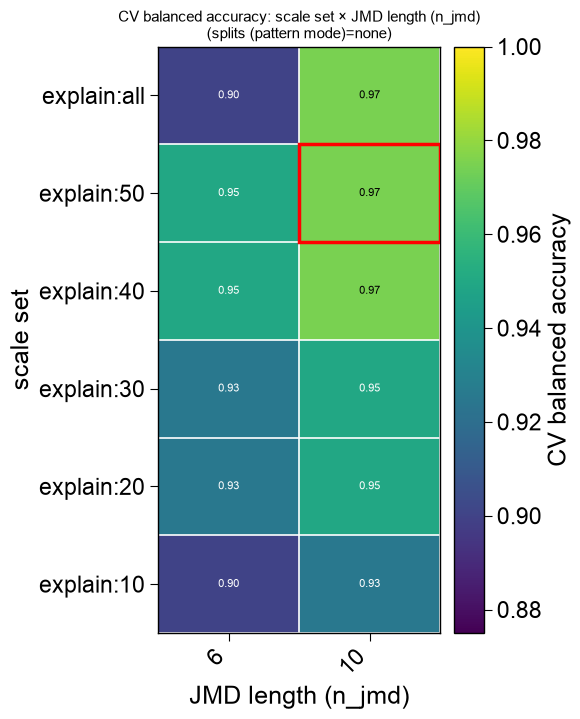

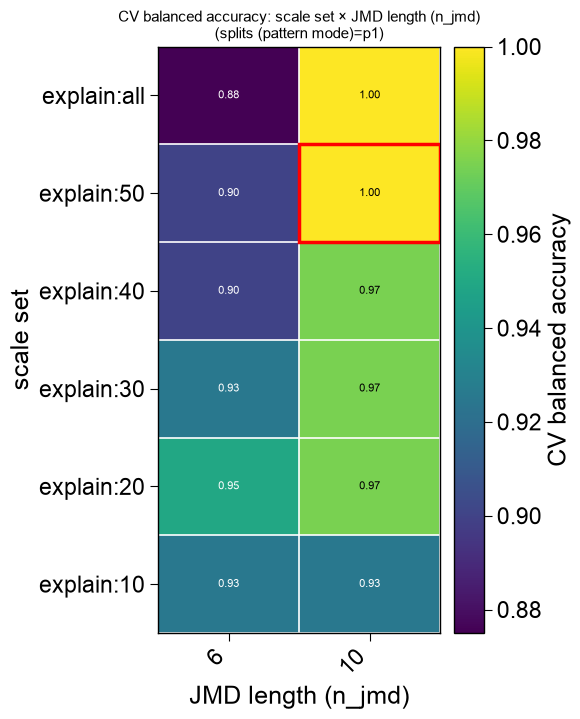

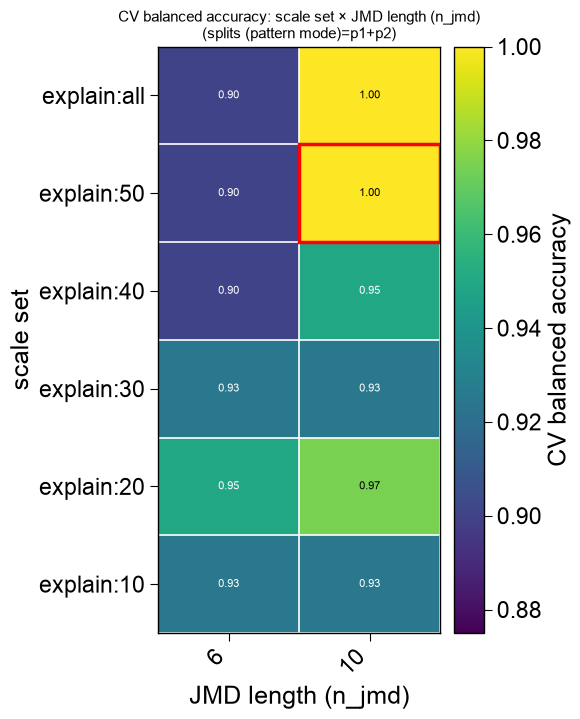

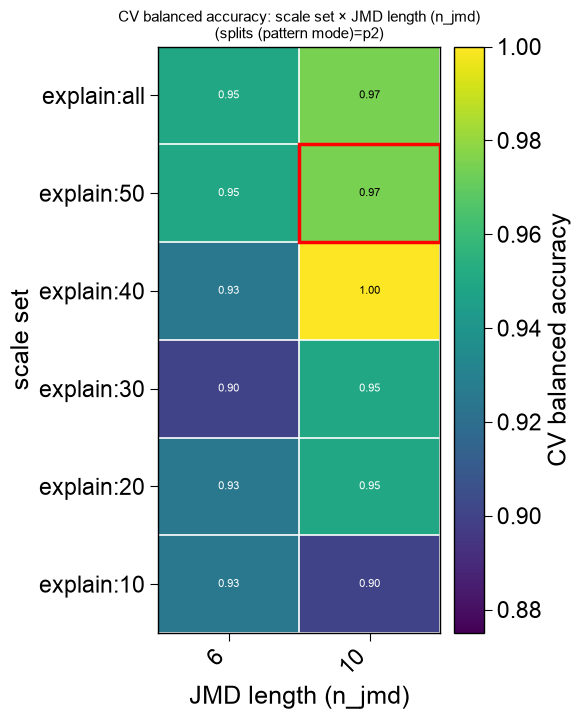

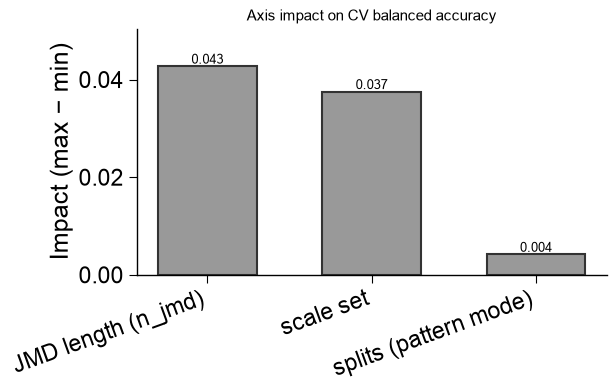

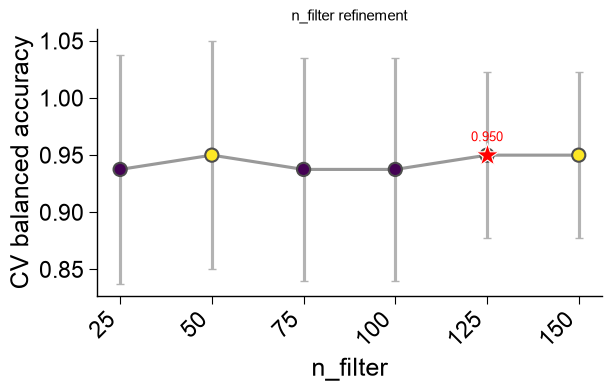

In [2]:
figs = aap.plot_eval(df_eval)
print(f"{len(figs)} publication eval figures")
plt.show()

Color by a specific ``metric`` (when several were optimized), pin the score column with ``score_col``, or set the per-figure ``figsize``. Each figure is a standalone ``matplotlib.figure.Figure`` you can save for a publication:

saved-ready figures: 6


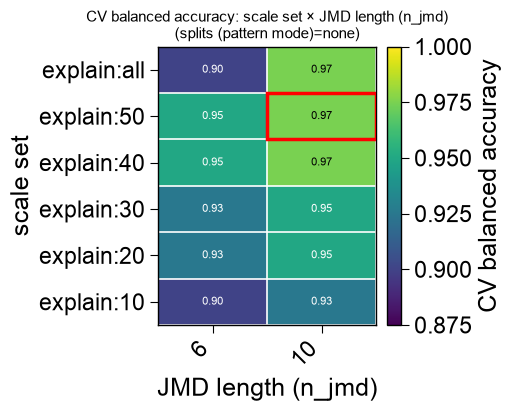

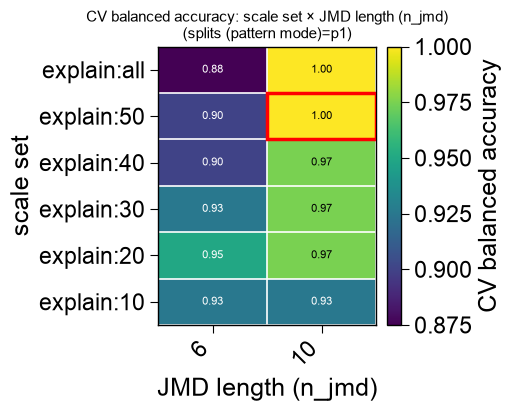

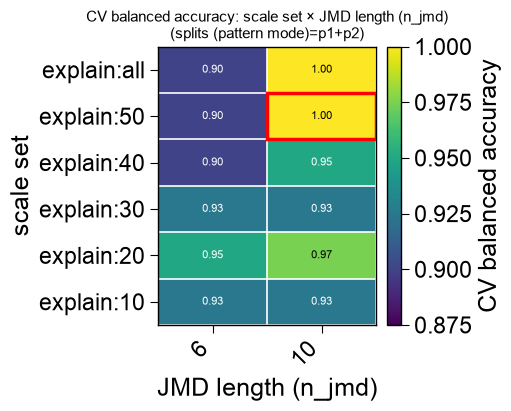

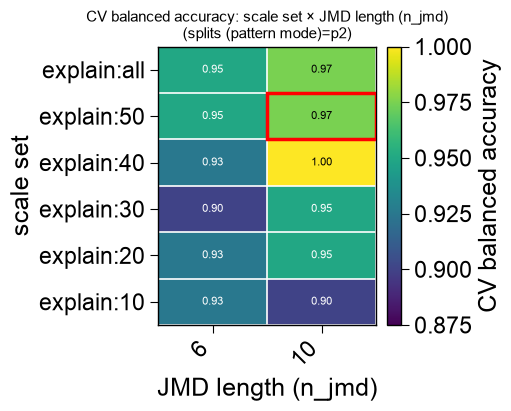

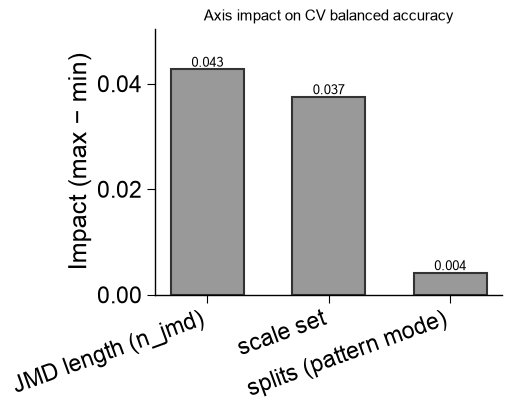

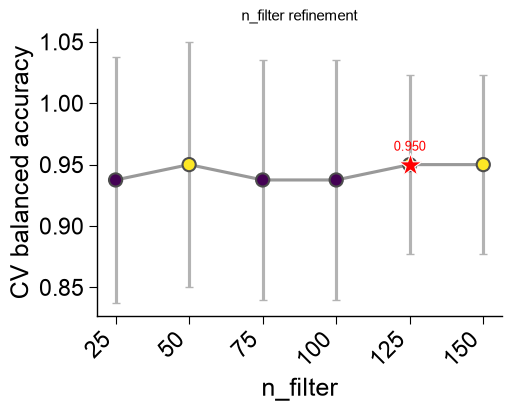

In [3]:
figs = aap.plot_eval(df_eval, metric="balanced_accuracy", figsize=(5, 4))
# figs[0].savefig("sweep_heatmap.png", dpi=300, bbox_inches="tight")
print(f"saved-ready figures: {len(figs)}")
plt.show()